# Beginner Tutorial: CNNs for Galaxy Morphology Classification

## A TensorFlow-free and PyTorch-free version that runs with NumPy

This notebook is a beginner-friendly case study on using **convolutional neural networks (CNNs)** for galaxy morphology.

Ref article, *Convolutional Neural Networks For Galaxy Morphology Classification*, but it avoids the TensorFlow DLL problem by using only:

- `numpy`
- `matplotlib`

The model here is intentionally small and educational. It trains a real, simple CNN layer from scratch using NumPy so you can see the core ideas without fighting deep-learning installation issues.

In [99]:
import math
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

SEED = 42
np.random.seed(SEED)

print("NumPy version:", np.__version__)
print("Matplotlib imported successfully.")

NumPy version: 1.26.2
Matplotlib imported successfully.


### Explanation of the code above

This setup cell imports the small set of libraries used throughout the notebook. `numpy` handles arrays and math, `matplotlib` draws images and graphs, and `sliding_window_view` helps us build a simple convolution operation from scratch. The random seed makes the synthetic galaxies and training results more repeatable, so beginners can rerun the notebook and see similar behavior.

## 2. Case-study 

The code is build around the article: "Convolutional Neural Networks For Galaxy Morphology Classification"  used the Galaxy Zoo / Kaggle galaxy morphology task as a CNN case study. The important ideas we will reuse are:

- **Inputs:** galaxy images.
- **Targets:** vote-proportion morphology labels, with values between 0 and 1.
- **Task type:** regression over probabilities, not ordinary single-class classification.
- **Preprocessing:** crop and downsample images to reduce memory and focus on the centered galaxy.
- **Augmentation:** rotate and flip images because morphology is largely orientation-invariant.
- **Model idea:** CNN layers extract visual patterns; a sigmoid output produces probability-like values.
- **Loss/metric:** mean squared error (MSE) and root mean squared error (RMSE).

The article reports that the real Galaxy Zoo setup used 37 output attributes. To keep this notebook beginner-friendly, we use 4 simplified morphology outputs:

```text
[smooth, disk, edge_on, spiral]
```

## 3. Create a tiny synthetic galaxy dataset

The real Galaxy Zoo images are large and must be downloaded separately. To make this notebook run anywhere, we create small synthetic galaxy-like images.

The synthetic images include:

- **smooth:** round or elliptical fuzzy blobs.
- **edge-on:** thin elongated disks with a bright center.
- **spiral:** disk-like objects with arm patterns.
- **odd:** irregular clumpy galaxies.

This synthetic data is only a teaching scaffold. It is not a scientific replacement for real survey data.

In [104]:
def coordinate_grid(size):
    """Return x/y coordinate grids in the range [-1, 1]."""
    ax = np.linspace(-1, 1, size, dtype=np.float32)
    xx, yy = np.meshgrid(ax, ax)
    return xx, yy


def rotate_coords(x, y, angle_rad):
    """Rotate coordinate grids by angle_rad."""
    ca, sa = np.cos(angle_rad), np.sin(angle_rad)
    xr = ca * x + sa * y
    yr = -sa * x + ca * y
    return xr, yr


def add_stars_gray(image, rng, n_stars=4):
    """Add small bright star-like points to a grayscale image."""
    h, w = image.shape
    for _ in range(n_stars):
        yy = rng.integers(0, h)
        xx = rng.integers(0, w)
        brightness = rng.uniform(0.25, 0.80)
        y0, y1 = max(0, yy - 1), min(h, yy + 2)
        x0, x1 = max(0, xx - 1), min(w, xx + 2)
        image[y0:y1, x0:x1] += brightness
    return image


def make_synthetic_galaxy(size=28, kind="smooth", rng=None):
    """
    Generate one synthetic grayscale galaxy image and a 4-output morphology target.

    Target order:
        [smooth, disk, edge_on, spiral]
    """
    if rng is None:
        rng = np.random.default_rng()

    x, y = coordinate_grid(size)
    xr, yr = rotate_coords(x, y, rng.uniform(0, 2 * np.pi))

    # Small random centering jitter.
    xr -= rng.normal(0, 0.02)
    yr -= rng.normal(0, 0.02)

    image = rng.normal(0.02, 0.01, size=(size, size)).astype(np.float32)

    if kind == "smooth":
        q = rng.uniform(0.70, 1.00)
        sigma = rng.uniform(0.22, 0.35)
        galaxy = np.exp(-((xr / sigma) ** 2 + (yr / (sigma * q)) ** 2))
        label = np.array([0.95, 0.10, 0.02, 0.03], dtype=np.float32)

    elif kind == "edge_on":
        sigma_x = rng.uniform(0.35, 0.52)
        sigma_y = rng.uniform(0.035, 0.065)
        disk = np.exp(-((xr / sigma_x) ** 2 + (yr / sigma_y) ** 2))
        bulge = 0.70 * np.exp(-((xr / 0.12) ** 2 + (yr / 0.12) ** 2))
        galaxy = disk + bulge
        label = np.array([0.10, 0.95, 0.95, 0.05], dtype=np.float32)

    elif kind == "spiral":
        r = np.sqrt(xr ** 2 + yr ** 2) + 1e-6
        theta = np.arctan2(yr, xr)
        disk = np.exp(-(r / 0.55) ** 2)
        arms = ((np.cos(2 * theta + 9 * r) + 1) / 2) ** 5
        galaxy = disk * (0.45 + 1.35 * arms)
        label = np.array([0.05, 0.95, 0.05, 0.95], dtype=np.float32)

    elif kind == "odd":
        galaxy = np.zeros((size, size), dtype=np.float32)
        for _ in range(rng.integers(2, 5)):
            bx, by = rng.normal(0, 0.35, size=2)
            sigma = rng.uniform(0.07, 0.18)
            blob = np.exp(-(((x - bx) / sigma) ** 2 + ((y - by) / sigma) ** 2))
            galaxy += rng.uniform(0.5, 1.2) * blob
        label = np.array([0.35, 0.45, 0.20, 0.25], dtype=np.float32)

    else:
        raise ValueError(f"Unknown kind: {kind}")

    image += galaxy.astype(np.float32)
    image = add_stars_gray(image, rng, n_stars=rng.integers(1, 6))
    image = np.clip(image, 0, 1).astype(np.float32)

    # Add small label noise to mimic uncertain human vote proportions.
    label = np.clip(label + rng.normal(0, 0.03, size=4), 0, 1).astype(np.float32)

    # Shape is H x W x C, where C=1 grayscale channel.
    return image[..., None], label


def make_dataset(n=160, size=28, seed=42):
    rng = np.random.default_rng(seed)
    kinds = np.array(["smooth", "edge_on", "spiral", "odd"])
    images, labels, names = [], [], []

    for _ in range(n):
        kind = rng.choice(kinds, p=[0.30, 0.25, 0.30, 0.15])
        image, label = make_synthetic_galaxy(size=size, kind=kind, rng=rng)
        images.append(image)
        labels.append(label)
        names.append(kind)

    return np.stack(images), np.stack(labels), np.array(names)


output_names = ["smooth", "disk", "edge_on", "spiral"]
X, y, kind_names = make_dataset(n=160, size=28, seed=SEED)

print("Images:", X.shape)   # N, height, width, channels
print("Targets:", y.shape)  # N, 4
print("Example target:", dict(zip(output_names, np.round(y[0], 2))))

Images: (160, 28, 28, 1)
Targets: (160, 4)
Example target: {'smooth': 0.01, 'disk': 0.97, 'edge_on': 0.06, 'spiral': 0.9}


### Explanation of the code above

This cell creates the teaching dataset. The helper functions build a coordinate grid, rotate coordinates, add small star-like pixels, and then generate four simplified galaxy types. Each synthetic image is paired with four probability-like morphology targets: `smooth`, `disk`, `edge_on`, and `spiral`. These targets imitate the article's key idea that Galaxy Zoo labels are vote proportions rather than a single hard class label. At the end, `make_dataset` collects many examples into `X` for images and `y` for targets.

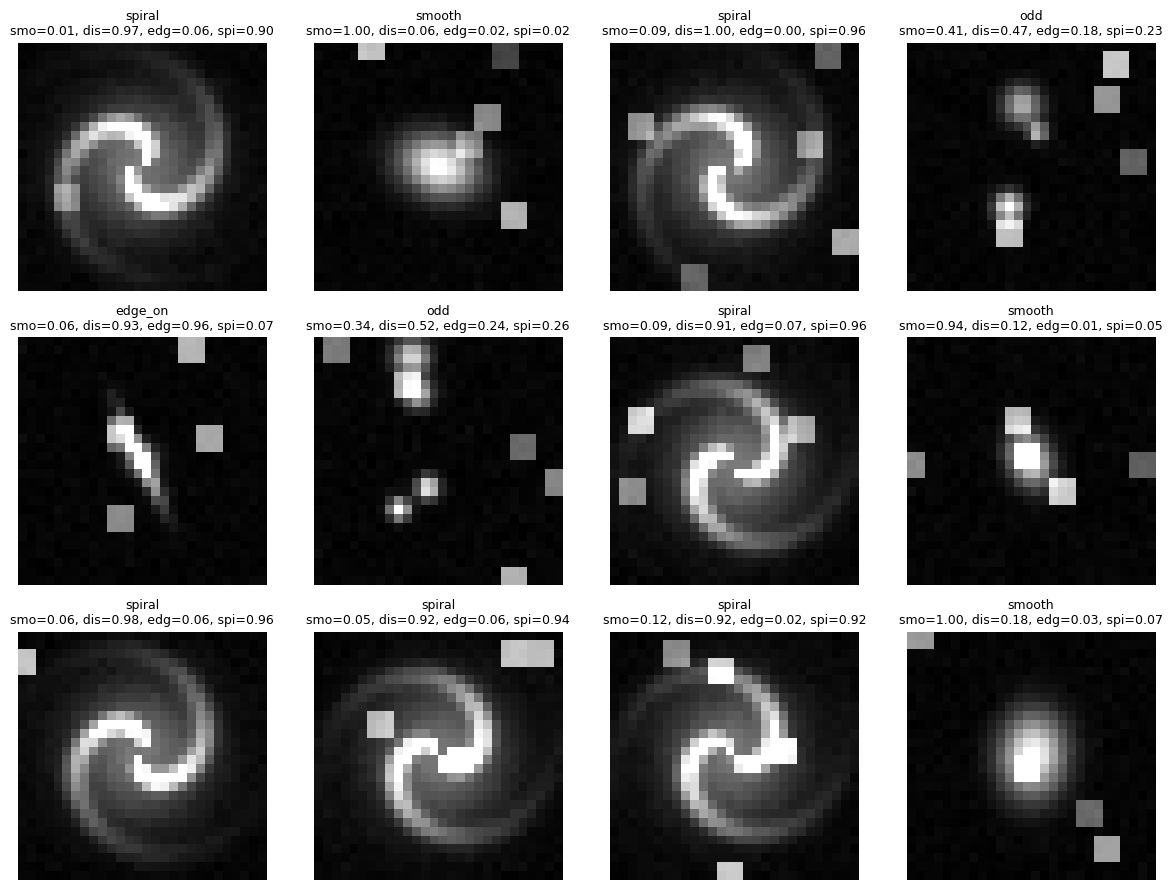

In [106]:
def show_examples(X, y, kind_names, n=12):
    indices = np.linspace(0, len(X) - 1, n, dtype=int)
    cols = 4
    rows = math.ceil(n / cols)
    plt.figure(figsize=(12, 3 * rows))

    for plot_i, idx in enumerate(indices, 1):
        plt.subplot(rows, cols, plot_i)
        plt.imshow(X[idx, :, :, 0], cmap="gray", vmin=0, vmax=1)
        target_text = ", ".join(
            f"{name[:3]}={value:.2f}" for name, value in zip(output_names, y[idx])
        )
        plt.title(f"{kind_names[idx]}\n{target_text}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_examples(X, y, kind_names)

### Explanation of the code above

This visualization function displays a small sample of the generated galaxies. For each image, it prints the synthetic galaxy type and the four target values above the plot. This is useful before training because it lets you check that the data and labels look reasonable.

## 4. Train/validation split

The article found that an 80/20 training-validation split behaved better than a 90/10 split in their experiments. We use the same idea here.

In [109]:
indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.80 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

print("Train images:", X_train.shape)
print("Validation images:", X_val.shape)

Train images: (128, 28, 28, 1)
Validation images: (32, 28, 28, 1)


### Explanation of the code above

This cell randomly shuffles the dataset and separates it into training and validation sets. The CNN learns from the training set, while the validation set is held back to estimate how well the model performs on images it did not train on. The 80/20 split mirrors the article's finding that a larger validation set gave more stable feedback than a 90/10 split.

## 5. Data augmentation with rotations and flips

A galaxy remains the same kind of galaxy after a 90-degree rotation or a left-right/up-down flip. This is why the article used random rotations and flips as augmentation.

The function below applies those transformations to a batch of images.

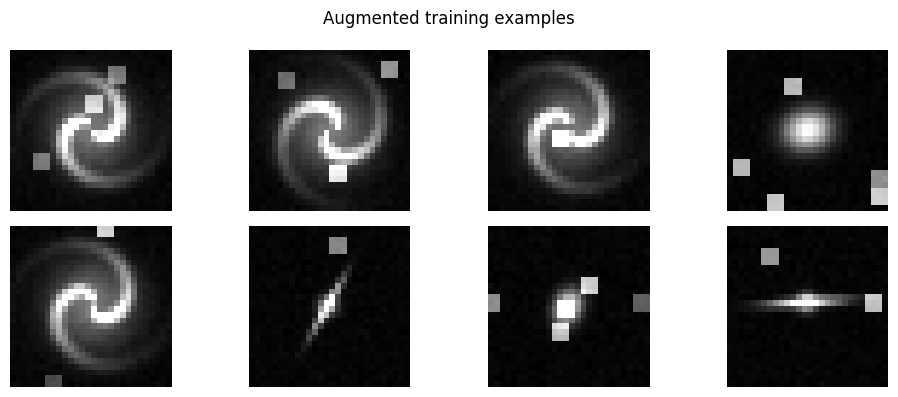

In [112]:
def augment_batch(X_batch):
    """Randomly rotate by 0/90/180/270 degrees and randomly flip each image."""
    X_aug = X_batch.copy()

    for i in range(len(X_aug)):
        k = np.random.randint(0, 4)
        X_aug[i] = np.rot90(X_aug[i], k=k, axes=(0, 1))

        if np.random.rand() > 0.5:
            X_aug[i] = np.flip(X_aug[i], axis=1)  # left/right
        if np.random.rand() > 0.5:
            X_aug[i] = np.flip(X_aug[i], axis=0)  # up/down

    # Avoid negative-stride issues caused by np.flip/np.rot90.
    return np.ascontiguousarray(X_aug)


augmented = augment_batch(X_train[:8])

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
plt.suptitle("Augmented training examples")
plt.tight_layout()
plt.show()

### Explanation of the code above

This function performs data augmentation. For every image in a batch, it randomly rotates the galaxy by 0, 90, 180, or 270 degrees and may flip it left-right or up-down. This is appropriate for galaxy morphology because a galaxy's type should not change just because the image is rotated or mirrored. The final `ascontiguousarray` call prevents array-layout issues that can happen after NumPy flips or rotations.

## 6. Build a tiny CNN from scratch with NumPy

This model is deliberately small:

```text
image
  -> trainable 5x5 convolution filters
  -> ReLU activation
  -> 2x2 average pooling
  -> flatten
  -> dense sigmoid output layer
  -> [smooth, disk, edge_on, spiral]
```

Why sigmoid? Each output should be a probability-like value between 0 and 1. We do **not** use softmax because these outputs are not one mutually exclusive class.

In [116]:
def sigmoid(z):
    """Numerically stable sigmoid."""
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))


def rmse(y_pred, y_true):
    """Root mean squared error."""
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def conv2d_same_forward(X_batch, W_conv, b_conv):
    """
    2D same-padding convolution for grayscale images.

    X_batch shape: N x H x W x 1
    W_conv shape : K x kernel_h x kernel_w
    Output shape : N x H x W x K
    """
    n, h, w, c = X_batch.shape
    n_filters, kernel_h, kernel_w = W_conv.shape
    pad = kernel_h // 2

    # This tutorial uses one grayscale channel for simplicity.
    X_padded = np.pad(
        X_batch[:, :, :, 0],
        pad_width=((0, 0), (pad, pad), (pad, pad)),
        mode="constant",
    )

    # patches shape: N x H x W x kernel_h x kernel_w
    patches = sliding_window_view(X_padded, (kernel_h, kernel_w), axis=(1, 2))

    # Convolution using Einstein summation.
    Z = np.einsum("nhwij,kij->nhwk", patches, W_conv, optimize=True)
    Z = Z + b_conv.reshape(1, 1, 1, n_filters)

    return Z, patches


def avg_pool2x2(A):
    """2x2 average pooling with stride 2."""
    return (
        A[:, 0::2, 0::2, :] +
        A[:, 1::2, 0::2, :] +
        A[:, 0::2, 1::2, :] +
        A[:, 1::2, 1::2, :]
    ) / 4


def avg_pool2x2_backward(dP, A_shape):
    """Backpropagation through 2x2 average pooling."""
    dA = np.zeros(A_shape, dtype=np.float32)
    share = dP / 4
    dA[:, 0::2, 0::2, :] += share
    dA[:, 1::2, 0::2, :] += share
    dA[:, 0::2, 1::2, :] += share
    dA[:, 1::2, 1::2, :] += share
    return dA


def initialize_parameters(image_size=28, n_filters=6, kernel_size=5, n_outputs=4, seed=42):
    rng = np.random.default_rng(seed)
    pooled_features = (image_size // 2) * (image_size // 2) * n_filters

    params = {
        "W_conv": rng.normal(0, 0.08, size=(n_filters, kernel_size, kernel_size)).astype(np.float32),
        "b_conv": np.zeros(n_filters, dtype=np.float32),
        "W_dense": rng.normal(0, 0.08, size=(pooled_features, n_outputs)).astype(np.float32),
        "b_dense": np.zeros(n_outputs, dtype=np.float32),
    }
    return params


def forward(X_batch, params):
    """Forward pass through the tiny CNN."""
    Z, patches = conv2d_same_forward(X_batch, params["W_conv"], params["b_conv"])
    A = np.maximum(Z, 0)                 # ReLU
    P = avg_pool2x2(A)                   # pooled feature maps
    F = P.reshape(len(X_batch), -1)       # flatten
    logits = F @ params["W_dense"] + params["b_dense"]
    y_pred = sigmoid(logits)

    cache = {
        "Z": Z,
        "A": A,
        "P": P,
        "F": F,
        "y_pred": y_pred,
        "patches": patches,
    }
    return y_pred, cache


params = initialize_parameters(image_size=X.shape[1], n_outputs=len(output_names), seed=SEED)

test_pred, test_cache = forward(X_train[:5], params)
print("Prediction shape:", test_pred.shape)
print("First untrained prediction:", np.round(test_pred[0], 3))

Prediction shape: (5, 4)
First untrained prediction: [0.506 0.46  0.525 0.48 ]


### Explanation of the code above

This cell defines the tiny CNN. `sigmoid` keeps each output between 0 and 1, which matches probability-like morphology labels. `rmse` measures prediction error. `conv2d_same_forward` applies learnable filters across each image, `avg_pool2x2` reduces the feature-map size, and `initialize_parameters` creates the trainable weights. The `forward` function combines these steps: convolution, ReLU activation, pooling, flattening, a dense layer, and sigmoid outputs. The short test at the end checks that the model can produce four predictions for a few images before training.

## 7. Train the CNN

We use mean squared error because the target values are probability-like vote fractions. RMSE is reported because it is easy to interpret and matches the evaluation style discussed in the article.

The training code below performs manual backpropagation through:

- sigmoid output
- dense layer
- average pooling
- ReLU
- convolution filters

This is exactly the kind of work TensorFlow or PyTorch usually handles for you automatically.

In [120]:
def train_numpy_cnn(X_train, y_train, X_val, y_val, epochs=20, batch_size=32, learning_rate=0.70):
    params = initialize_parameters(image_size=X_train.shape[1], n_outputs=y_train.shape[1], seed=SEED)
    history = {"loss": [], "val_loss": [], "rmse": [], "val_rmse": []}
    n_train = len(X_train)

    for epoch in range(1, epochs + 1):
        order = np.random.permutation(n_train)

        for start in range(0, n_train, batch_size):
            batch_idx = order[start:start + batch_size]
            X_batch = augment_batch(X_train[batch_idx])
            y_batch = y_train[batch_idx]

            y_pred, cache = forward(X_batch, params)

            # d/d prediction of mean squared error.
            dY = 2 * (y_pred - y_batch) / y_batch.size

            # Backprop through sigmoid.
            dlogits = dY * y_pred * (1 - y_pred)

            # Backprop through dense layer.
            F = cache["F"]
            dW_dense = F.T @ dlogits
            db_dense = dlogits.sum(axis=0)
            dF = dlogits @ params["W_dense"].T

            # Backprop through reshape and average pooling.
            P = cache["P"]
            A = cache["A"]
            dP = dF.reshape(P.shape)
            dA = avg_pool2x2_backward(dP, A.shape)

            # Backprop through ReLU.
            Z = cache["Z"]
            dZ = dA * (Z > 0)

            # Backprop to convolution filter weights and biases.
            patches = cache["patches"]
            dW_conv = np.einsum("nhwij,nhwk->kij", patches, dZ, optimize=True)
            db_conv = dZ.sum(axis=(0, 1, 2))

            # Gradient descent update.
            params["W_dense"] -= learning_rate * dW_dense.astype(np.float32)
            params["b_dense"] -= learning_rate * db_dense.astype(np.float32)
            params["W_conv"] -= learning_rate * dW_conv.astype(np.float32)
            params["b_conv"] -= learning_rate * db_conv.astype(np.float32)

        train_pred, _ = forward(X_train, params)
        val_pred, _ = forward(X_val, params)

        train_mse = float(np.mean((train_pred - y_train) ** 2))
        val_mse = float(np.mean((val_pred - y_val) ** 2))

        history["loss"].append(train_mse)
        history["val_loss"].append(val_mse)
        history["rmse"].append(math.sqrt(train_mse))
        history["val_rmse"].append(math.sqrt(val_mse))

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train RMSE={history['rmse'][-1]:.4f} | "
                f"val RMSE={history['val_rmse'][-1]:.4f}"
            )

    return params, history


params, history = train_numpy_cnn(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    batch_size=32,
    learning_rate=0.70,
)

Epoch 01/20 | train RMSE=0.4061 | val RMSE=0.4343
Epoch 05/20 | train RMSE=0.3687 | val RMSE=0.4065
Epoch 10/20 | train RMSE=0.2826 | val RMSE=0.3408
Epoch 15/20 | train RMSE=0.2314 | val RMSE=0.2804
Epoch 20/20 | train RMSE=0.2038 | val RMSE=0.2316


Epoch 15/20 | train RMSE=0.2314 | val RMSE=0.2804


Epoch 20/20 | train RMSE=0.2038 | val RMSE=0.2316


### Explanation of the code above

This cell trains the CNN using manual backpropagation. For each epoch, the data is shuffled, split into mini-batches, augmented, and passed through the model. The code computes mean squared error, works backward through the sigmoid, dense layer, pooling layer, ReLU, and convolution filters, then updates the weights using gradient descent. After each epoch, it records training and validation MSE/RMSE so we can see whether the model is learning or overfitting.

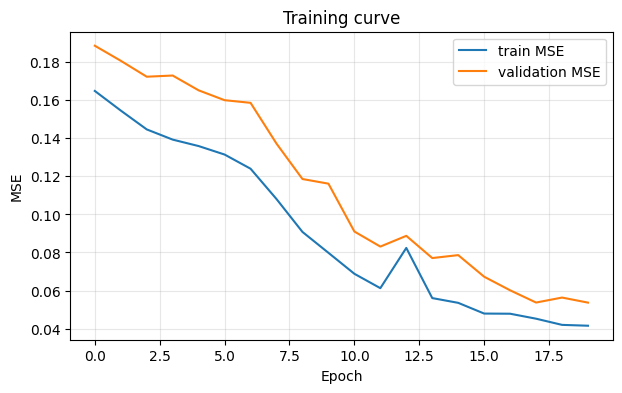

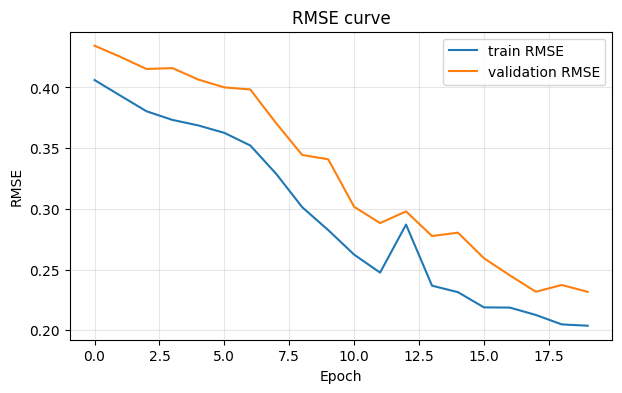

In [123]:
def plot_history(history):
    plt.figure(figsize=(7, 4))
    plt.plot(history["loss"], label="train MSE")
    plt.plot(history["val_loss"], label="validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Training curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history["rmse"], label="train RMSE")
    plt.plot(history["val_rmse"], label="validation RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("RMSE curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_history(history)

### Explanation of the code above

This function plots the training history. The first graph shows mean squared error, and the second graph shows RMSE. The training curve tells us how well the model fits the training data, while the validation curve tells us whether the learned patterns generalize to unseen examples.

## 8. Evaluate predictions

A lower RMSE means the predicted vote proportions are closer to the target vote proportions.

In [126]:
val_pred, _ = forward(X_val, params)

print(f"Validation RMSE: {rmse(val_pred, y_val):.4f}")
print()

per_output_rmse = np.sqrt(np.mean((val_pred - y_val) ** 2, axis=0))
for name, score in zip(output_names, per_output_rmse):
    print(f"{name:8s} RMSE: {score:.4f}")

Validation RMSE: 0.2316

smooth   RMSE: 0.2444
disk     RMSE: 0.2435
edge_on  RMSE: 0.3057
spiral   RMSE: 0.0463


### Explanation of the code above

This cell evaluates the trained CNN on the validation set. First it reports the overall validation RMSE across all outputs. Then it computes a separate RMSE for each morphology output, which helps identify whether the model is better at predicting some features, such as `smooth`, than others, such as `spiral`.

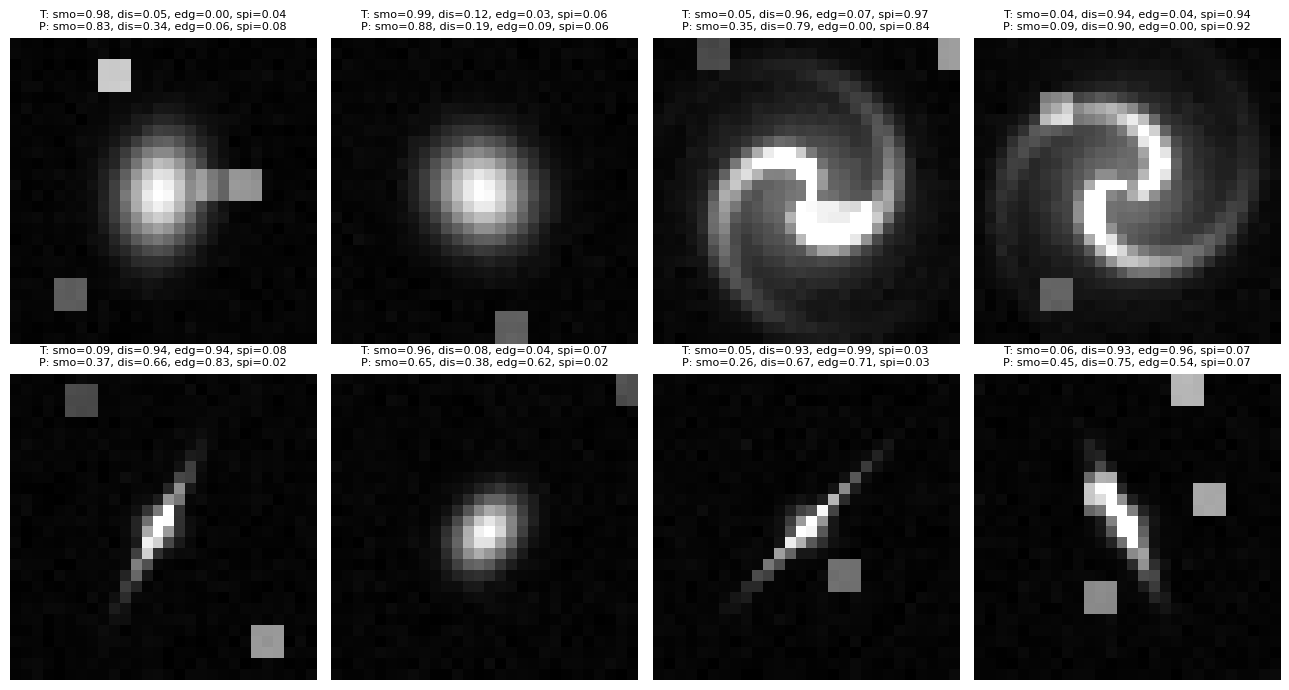

In [128]:
def show_predictions(X, y_true, y_pred, n=8):
    indices = np.random.choice(len(X), size=min(n, len(X)), replace=False)
    cols = 4
    rows = math.ceil(len(indices) / cols)
    plt.figure(figsize=(13, 3.5 * rows))

    for plot_i, idx in enumerate(indices, 1):
        plt.subplot(rows, cols, plot_i)
        plt.imshow(X[idx, :, :, 0], cmap="gray", vmin=0, vmax=1)

        true_text = "T: " + ", ".join(
            f"{name[:3]}={value:.2f}" for name, value in zip(output_names, y_true[idx])
        )
        pred_text = "P: " + ", ".join(
            f"{name[:3]}={value:.2f}" for name, value in zip(output_names, y_pred[idx])
        )
        plt.title(true_text + "\n" + pred_text, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(X_val, y_val, val_pred, n=8)

### Explanation of the code above

This function shows example validation predictions. Each image displays two lines: `T` for the true target values and `P` for the model's predicted values. This makes the model's behavior easier to understand than a single RMSE number because you can visually compare predictions with the galaxy image.

## 9. Visualize the learned convolution filters

The filters below started as random numbers. During training, the CNN adjusted them to respond to useful image patterns.

In a larger real CNN, early filters often learn edges, blobs, and simple textures; deeper filters combine these into more meaningful structures.

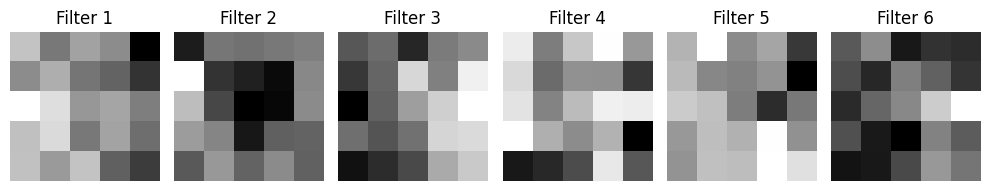

In [132]:
filters = params["W_conv"]

plt.figure(figsize=(10, 3))
for i in range(filters.shape[0]):
    plt.subplot(1, filters.shape[0], i + 1)
    plt.imshow(filters[i], cmap="gray")
    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Explanation of the code above

This cell visualizes the convolution filters learned by the model. These filters started as random numbers and were adjusted during training. In a CNN, early filters often become detectors for simple patterns such as bright centers, edges, elongated structures, or blobs.

## 10. How this maps to the real Galaxy Zoo task

For real Galaxy Zoo data, you would replace the synthetic dataset with actual image files and the 4-output labels with 37 vote-proportion columns.

Typical real-data pipeline:

1. Load image file by `GalaxyID`.
2. Center-crop the galaxy.
3. Resize/downsample the image.
4. Normalize pixel values to `[0, 1]`.
5. Predict 37 sigmoid outputs.
6. Train with MSE and monitor RMSE.

The article's VGG-style approach was much deeper than this tutorial model. A full production notebook would normally use PyTorch, TensorFlow, or JAX once the Python environment is stable.

In [93]:
# OPTIONAL REAL-DATA TEMPLATE
# This cell is intentionally commented out so the notebook runs without downloads.
#
# Expected Kaggle-style layout after downloading/unzipping:
#
# data/galaxy_zoo/
#   training_solutions_rev1.csv
#   images_training_rev1/
#       100008.jpg
#       100023.jpg
#       ...
#
# from pathlib import Path
# import pandas as pd
# from PIL import Image
#
# DATA_DIR = Path("data/galaxy_zoo")
# CSV_PATH = DATA_DIR / "training_solutions_rev1.csv"
# IMAGE_DIR = DATA_DIR / "images_training_rev1"
#
# labels_df = pd.read_csv(CSV_PATH)
# id_col = "GalaxyID"
# target_cols = [c for c in labels_df.columns if c != id_col]
# print("Number of targets:", len(target_cols))  # Galaxy Zoo uses 37.
#
# def load_and_preprocess_real_image(galaxy_id, img_size=106, crop_fraction=0.50):
#     image_path = IMAGE_DIR / f"{int(galaxy_id)}.jpg"
#     image = Image.open(image_path).convert("L")  # grayscale for this NumPy tutorial
#
#     width, height = image.size
#     crop_size = int(min(width, height) * crop_fraction)
#     left = (width - crop_size) // 2
#     top = (height - crop_size) // 2
#     image = image.crop((left, top, left + crop_size, top + crop_size))
#     image = image.resize((img_size, img_size))
#
#     array = np.asarray(image).astype("float32") / 255.0
#     return array[..., None]

### Explanation of the code above

This optional template shows how the synthetic dataset could be replaced with real Galaxy Zoo files. It is commented out so the notebook runs without downloading any external data. In a real project, you would read the CSV of morphology vote proportions, load each image by `GalaxyID`, crop and resize it, normalize pixel values, and train a CNN with 37 sigmoid outputs instead of the four simplified outputs used in this tutorial.

## 11. Common beginner mistakes

### Mistake 1: Treating morphology as one-class classification
Galaxy morphology labels are probability-like vote proportions. Use regression-style outputs or multi-label-style outputs.

### Mistake 2: Using softmax for all outputs
Softmax forces outputs to sum to 1. That is usually wrong for this task. Use sigmoid outputs instead.

### Mistake 3: Forgetting orientation invariance
A rotated galaxy is still the same galaxy. Rotations and flips are sensible augmentations.

### Mistake 4: Starting too large
A VGG-style network is useful for serious experiments, but beginners should first validate the data pipeline with a tiny model.

### Mistake 5: Looking only at training loss
Always compare training and validation curves. If training improves while validation worsens, the model is overfitting.

## 12. Exercises

Try these changes:

1. Set `epochs=40`. Does validation RMSE improve or plateau?
2. Disable augmentation by replacing `X_batch = augment_batch(...)` with the original batch. What changes?
3. Change `n_filters` from 6 to 10 in `initialize_parameters`. Does the model improve?
4. Add a fifth output called `odd`. How would you change the labels and output layer?
5. Increase `size=56` in `make_dataset`. What happens to runtime?
6. Replace average pooling with global average pooling. Does performance change?

---

## Final takeaway

CNNs are useful for galaxy morphology because they learn visual patterns directly from pixels. In the real Galaxy Zoo task, those patterns are used to predict many human vote-proportion attributes, making the task closer to multi-output regression than ordinary image classification.